In [1]:
import pandas as pd
import numpy as np

In [2]:
anime = pd.read_csv("anime-dataset-2023.csv")

In [3]:
anime.info()

<class 'pandas.DataFrame'>
RangeIndex: 24905 entries, 0 to 24904
Data columns (total 24 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   anime_id      24905 non-null  int64
 1   Name          24905 non-null  str  
 2   English name  24905 non-null  str  
 3   Other name    24905 non-null  str  
 4   Score         24905 non-null  str  
 5   Genres        24905 non-null  str  
 6   Synopsis      24905 non-null  str  
 7   Type          24905 non-null  str  
 8   Episodes      24905 non-null  str  
 9   Aired         24905 non-null  str  
 10  Premiered     24905 non-null  str  
 11  Status        24905 non-null  str  
 12  Producers     24905 non-null  str  
 13  Licensors     24905 non-null  str  
 14  Studios       24905 non-null  str  
 15  Source        24905 non-null  str  
 16  Duration      24905 non-null  str  
 17  Rating        24905 non-null  str  
 18  Rank          24905 non-null  str  
 19  Popularity    24905 non-null  int64


In [38]:
required_columns = ["Name", "English name", "Genres", "Synopsis", "Type", "Studios", "Source","Rank", "Popularity", "Favorites", "Scored By"]

df = anime[required_columns]
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24905 entries, 0 to 24904
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Name          24905 non-null  str  
 1   English name  24905 non-null  str  
 2   Genres        24905 non-null  str  
 3   Synopsis      24905 non-null  str  
 4   Type          24905 non-null  str  
 5   Studios       24905 non-null  str  
 6   Source        24905 non-null  str  
 7   Rank          24905 non-null  str  
 8   Popularity    24905 non-null  int64
 9   Favorites     24905 non-null  int64
 10  Scored By     24905 non-null  str  
dtypes: int64(2), str(9)
memory usage: 2.1 MB


In [5]:
df[required_columns].isnull().sum()

Name            0
English name    0
Genres          0
Synopsis        0
Type            0
Studios         0
Source          0
dtype: int64

In [6]:
for col in required_columns:
    print(f"{col}: {(df[col] == 'UNKNOWN').sum()}")

Name: 0
English name: 14577
Genres: 4929
Synopsis: 0
Type: 74
Studios: 10526
Source: 0


In [7]:
df[required_columns] = df[required_columns].replace("UNKNOWN","").fillna("")

In [8]:
df["synopsis_length"] = df["Synopsis"].fillna("").str.split().str.len()

df["synopsis_length"].describe()

count    24905.000000
mean        54.334069
std         57.637303
min          2.000000
25%          8.000000
50%         29.000000
75%         86.000000
max        638.000000
Name: synopsis_length, dtype: float64

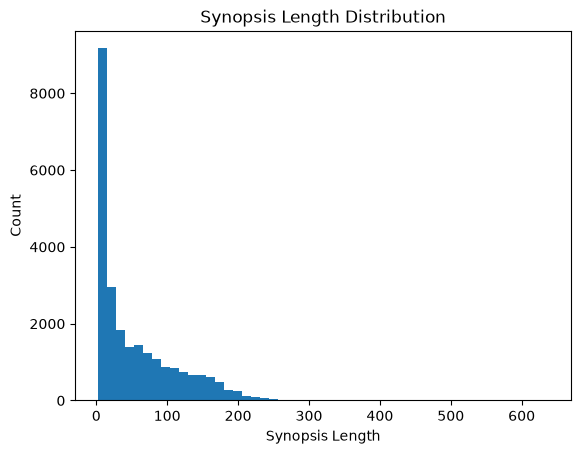

In [9]:
import matplotlib.pyplot as plt

plt.hist(df["synopsis_length"], bins=50)
plt.xlabel("Synopsis Length")
plt.ylabel("Count")
plt.title("Synopsis Length Distribution")
plt.show()

In [10]:
from collections import Counter

genres = Counter()

for g in df["Genres"].dropna():
    genres.update([x.strip() for x in g.split(",")])

genres.most_common(20)

[('Comedy', 7142),
 ('Fantasy', 5306),
 ('', 4929),
 ('Action', 4730),
 ('Adventure', 3842),
 ('Sci-Fi', 3091),
 ('Drama', 2836),
 ('Romance', 2063),
 ('Slice of Life', 1755),
 ('Supernatural', 1494),
 ('Hentai', 1486),
 ('Mystery', 847),
 ('Avant Garde', 804),
 ('Ecchi', 795),
 ('Sports', 771),
 ('Horror', 534),
 ('Suspense', 242),
 ('Award Winning', 241),
 ('Boys Love', 169),
 ('Gourmet', 146)]

In [11]:
df["Studios"].value_counts().head(20)

Studios
                                  10526
Toei Animation                      834
Sunrise                             532
J.C.Staff                           385
Shanghai Animation Film Studio      335
Madhouse                            333
TMS Entertainment                   317
Studio Deen                         290
Production I.G                      269
Pierrot                             264
OLM                                 246
A-1 Pictures                        221
Nippon Animation                    209
Shin-Ei Animation                   203
DLE                                 189
Tatsunoko Production                157
AIC                                 152
Bones                               143
T-Rex                               129
Gonzo                               123
Name: count, dtype: int64

In [12]:
def create_combined_data(row):
    parts = []

    if row["Genres"]:
        parts.append(f"Genres: {row['Genres']}.")

    if row["Type"]:
        parts.append(f"Type: {row['Type']}.")

    if row["Source"]:
        parts.append(f"Source: {row['Source']}.")

    if row["Studios"]:
        parts.append(f"Studio: {row['Studios']}.")

    if row["Synopsis"]:
        parts.append(f"Synopsis: {row['Synopsis']}")

    return " ".join(parts)

In [13]:
df["matter"] = df.apply(create_combined_data, axis=1)

In [14]:
df['matter'].iloc[0]

"Genres: Action, Award Winning, Sci-Fi. Type: TV. Source: Original. Studio: Sunrise. Synopsis: Crime is timeless. By the year 2071, humanity has expanded across the galaxy, filling the surface of other planets with settlements like those on Earth. These new societies are plagued by murder, drug use, and theft, and intergalactic outlaws are hunted by a growing number of tough bounty hunters.\n\nSpike Spiegel and Jet Black pursue criminals throughout space to make a humble living. Beneath his goofy and aloof demeanor, Spike is haunted by the weight of his violent past. Meanwhile, Jet manages his own troubled memories while taking care of Spike and the Bebop, their ship. The duo is joined by the beautiful con artist Faye Valentine, odd child Edward Wong Hau Pepelu Tivrusky IV, and Ein, a bioengineered Welsh Corgi.\n\nWhile developing bonds and working to catch a colorful cast of criminals, the Bebop crew's lives are disrupted by a menace from Spike's past. As a rival's maniacal plot conti

In [15]:
df['matter'] = df['matter'].str.replace("\n", " ")
df['matter'].iloc[0]

"Genres: Action, Award Winning, Sci-Fi. Type: TV. Source: Original. Studio: Sunrise. Synopsis: Crime is timeless. By the year 2071, humanity has expanded across the galaxy, filling the surface of other planets with settlements like those on Earth. These new societies are plagued by murder, drug use, and theft, and intergalactic outlaws are hunted by a growing number of tough bounty hunters.  Spike Spiegel and Jet Black pursue criminals throughout space to make a humble living. Beneath his goofy and aloof demeanor, Spike is haunted by the weight of his violent past. Meanwhile, Jet manages his own troubled memories while taking care of Spike and the Bebop, their ship. The duo is joined by the beautiful con artist Faye Valentine, odd child Edward Wong Hau Pepelu Tivrusky IV, and Ein, a bioengineered Welsh Corgi.  While developing bonds and working to catch a colorful cast of criminals, the Bebop crew's lives are disrupted by a menace from Spike's past. As a rival's maniacal plot continues

In [16]:
from sentence_transformers import SentenceTransformer

In [17]:
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [18]:
sample_text = df['matter'].iloc[0]
sample_text

"Genres: Action, Award Winning, Sci-Fi. Type: TV. Source: Original. Studio: Sunrise. Synopsis: Crime is timeless. By the year 2071, humanity has expanded across the galaxy, filling the surface of other planets with settlements like those on Earth. These new societies are plagued by murder, drug use, and theft, and intergalactic outlaws are hunted by a growing number of tough bounty hunters.  Spike Spiegel and Jet Black pursue criminals throughout space to make a humble living. Beneath his goofy and aloof demeanor, Spike is haunted by the weight of his violent past. Meanwhile, Jet manages his own troubled memories while taking care of Spike and the Bebop, their ship. The duo is joined by the beautiful con artist Faye Valentine, odd child Edward Wong Hau Pepelu Tivrusky IV, and Ein, a bioengineered Welsh Corgi.  While developing bonds and working to catch a colorful cast of criminals, the Bebop crew's lives are disrupted by a menace from Spike's past. As a rival's maniacal plot continues

In [19]:
embedding = model.encode(sample_text)
print(type(embedding))
print(embedding.shape)

<class 'numpy.ndarray'>
(384,)


In [20]:
sample_encoding = model.encode(df["matter"].head(5).to_list())
print(sample_encoding.shape)

(5, 384)


Generating Full Encoding

In [21]:
import os

if os.path.exists("embeddings.npy"):
    print("Loading existing embeddings...")
    embeddings = np.load("embeddings.npy")
else:
    print("Generating embeddings...")
    embeddings = model.encode(
        df["matter"].tolist(),
        batch_size=32,
        show_progress_bar=True,
        convert_to_numpy=True
    )

    np.save("embeddings.npy", embeddings)
    print("Embeddings saved successfully!")

Loading existing embeddings...


In [22]:
embeddings.shape

(24905, 384)

In [23]:
%pip install faiss-cpu

Note: you may need to restart the kernel to use updated packages.


In [24]:
import faiss

In [25]:
if os.path.exists("matter_faiss.index"):
    print("Loading existing FAISS index")
    index = faiss.read_index("matter_faiss.index")
else:
    print("Creating new FAISS index")
    faiss.normalize_L2(embeddings)
    index = faiss.IndexFlatIP(384)
    index.add(embeddings)
    faiss.write_index(index, "matter_faiss.index")
    print("FAISS index saved successfully!")

Loading existing FAISS index


Test working with single text

In [26]:
query = "I want popular romance and isekai animes"
query_embedding = model.encode([query])
query_embedding.shape

(1, 384)

In [27]:
faiss.normalize_L2(query_embedding)
distances,indices =index.search(query_embedding,5)
print(distances)
print(indices)

[[0.69056654 0.66110003 0.6485485  0.642465   0.639023  ]]
[[20984 24172 23722 11071 21514]]


In [28]:
print(df.iloc[20984]["Name"])


Isekai Maou to Shoukan Shoujo no Dorei Majutsu Ω Mini Anime


In [29]:
def search_anime(query, k=5):
    query_embedding = model.encode([query])
    faiss.normalize_L2(query_embedding)
    distances, indices = index.search(query_embedding, k)

    for score,id in zip(distances[0], indices[0]):
        print(f"Title: {df.iloc[id]['Name']}, score: {score:.4f}")
        

In [30]:
search_anime("I want romance anime")

Title: Nuhai, Ni De Yi Fenzhong You Duo Zhang, score: 0.6876
Title: Huixiang, score: 0.6876
Title: Ai Ni Zhidao Shijie Jintou, score: 0.6809
Title: Ming Ji, score: 0.6809
Title: Yunduan Di Rizi, score: 0.6809


In [31]:
print(df.loc[df["Name"] == "Horimiya", "matter"].values[0])

Genres: Romance. Type: TV. Source: Manga. Studio: CloverWorks. Synopsis: On the surface, the thought of Kyouko Hori and Izumi Miyamura getting along would be the last thing in people's minds. After all, Hori has a perfect combination of beauty and brains, while Miyamura appears meek and distant to his fellow classmates. However, a fateful meeting between the two lays both of their hidden selves bare. Even though she is popular at school, Hori has little time to socialize with her friends due to housework. On the other hand, Miyamura lives under the noses of his peers, his body bearing secret tattoos and piercings that make him look like a gentle delinquent.  Having opposite personalities yet sharing odd similarities, the two quickly become friends and often spend time together in Hori's home. As they both emerge from their shells, they share with each other a side of themselves concealed from the outside world.


In [32]:
search_anime(
    "high school romantic comedy manga adaptation"
)

Title: Danchi Tomoo, score: 0.6712
Title: Dounika Naru Hibi, score: 0.6632
Title: Kochira Katsushikaku Kameari Kouenmae Hashutsujo: Ryoutsu no Asakusa Renewal Daisakusen!! - Aa, Omoide no Hanayashiki, score: 0.6567
Title: Gokujo.: Souda Onsen ni Ikou!!, score: 0.6525
Title: Gorillaman, score: 0.6456


In [33]:
search_anime(
    "Genres: Romance. Type: TV. Source: Manga."
)

Title: Kyoushirou to Towa no Sora Specials, score: 0.8673
Title: Horimiya: Piece, score: 0.8604
Title: Eternity: Shinya no Nurekoi Channel ♡, score: 0.8522
Title: Subarashii Shin Sekai, score: 0.8453
Title: Dear Brave, score: 0.8453


In [34]:
search_anime(
    df.loc[df["Name"]=="Horimiya", "matter"].iloc[0]
)

Title: Horimiya, score: 1.0000
Title: Hori-san to Miyamura-kun, score: 0.8205
Title: Souryo to Majiwaru Shikiyoku no Yoru ni..., score: 0.6762
Title: Hidamari Sketch, score: 0.6358
Title: Marmalade Boy, score: 0.6339


In [35]:
search_anime('an anime where love bloosoms in school and they end up together in the same house ')

Title: Dounika Naru Hibi, score: 0.6435
Title: Hirano to Kagiura, score: 0.6384
Title: Kimagure Orange☆Road: Ano Hi ni Kaeritai, score: 0.5881
Title: School Days, score: 0.5806
Title: Choujigen Kakumei Anime: Dimension High School, score: 0.5789


In [39]:
cols = ["Rank", "Popularity", "Favorites", "Scored By"]

for col in cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [44]:
df[cols].fillna(0)

,Rank,Popularity,Favorites,Scored By
0,41.0,43,78525,914193.0
1,189.0,602,1448,206248.0
2,328.0,246,15035,356739.0
3,2764.0,1795,613,42829.0
4,4240.0,5126,14,6413.0
...,...,...,...,...
24900,0.0,24723,0,0.0
24901,0.0,0,0,0.0
24902,0.0,0,0,0.0
24903,0.0,0,0,0.0


In [50]:
print(df[["Rank","Popularity","Favorites","Scored By"]].isna().sum())

Rank          4612
Popularity       0
Favorites        0
Scored By     9213
dtype: int64


In [51]:
df["Rank"] = df["Rank"].fillna(df["Rank"].max() + 1)

df["Scored By"] = df["Scored By"].fillna(0)

In [53]:
from sklearn.preprocessing import MinMaxScaler


scaler = MinMaxScaler()

# Rank (smaller is better)
df["rank_score"] = 1 - scaler.fit_transform(df[["Rank"]])

# Popularity (smaller is better)
df["popularity_score"] = 1 - scaler.fit_transform(df[["Popularity"]])

# Favorites (larger is better)
df["favorites_score"] = scaler.fit_transform(
    np.log1p(df[["Favorites"]])
)

# Scored By (larger is better)
df["scored_by_score"] = scaler.fit_transform(
    np.log1p(df[["Scored By"]])
)

In [54]:
df["importance_score"] = (
    0.40 * df["popularity_score"]
    + 0.25 * df["favorites_score"]
    + 0.20 * df["scored_by_score"]
    + 0.15 * df["rank_score"]
)

In [59]:
def search_anime_improved(query, k=5):
    query_embedding = model.encode([query])
    faiss.normalize_L2(query_embedding)

    # Retrieve more candidates for reranking
    distances, indices = index.search(query_embedding, 50)

    results = []

    for similarity, idx in zip(distances[0], indices[0]):
        importance = df.iloc[idx]["importance_score"]

        final_score = (
            0.70 * similarity +
            0.30 * importance
        )

        results.append({
            "title": df.iloc[idx]["Name"],
            "semantic_score": similarity,
            "importance_score": importance,
            "final_score": final_score
        })

    # Sort by final score
    results.sort(key=lambda x: x["final_score"], reverse=True)

    # Print top-k results
    for anime in results[:k]:
        print(
            f"Title: {anime['title']}\n"
            f"Semantic Score : {anime['semantic_score']:.4f}\n"
            f"Importance Score: {anime['importance_score']:.4f}\n"
            f"Final Score    : {anime['final_score']:.4f}\n"
        )

In [60]:
search_anime_improved(
    "high school romantic comedy manga adaptation"
)

Title: School Rumble
Semantic Score : 0.6270
Importance Score: 0.8679
Final Score    : 0.6993

Title: Kimi to Boku.
Semantic Score : 0.6234
Importance Score: 0.8170
Final Score    : 0.6815

Title: Danshi Koukousei no Nichijou Specials
Semantic Score : 0.6410
Importance Score: 0.7757
Final Score    : 0.6814

Title: Junjou Romantica 2
Semantic Score : 0.6180
Importance Score: 0.8173
Final Score    : 0.6778

Title: Paniponi Dash!
Semantic Score : 0.6093
Importance Score: 0.7507
Final Score    : 0.6517

